In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
filename = r'..\data\results\game_dataset.csv'
df = pd.read_csv(filename)
df.rename(columns={'mode': 'condition'}, inplace=True)

In [3]:
subject = ['01TG', '02ES', '03AC', '04AB', '06KK', '07TS', '10AS', '11AK',
       '13AU', '14BE', '15AZ', '18KK', '19VB', '20EC', '21EC', '22ES',
       '23MM', '24EK', '25PP']

In [4]:
order = np.array('1 2 1 2 1 1 2 2 1 2 2 1 2 2 1 1 2 1 1'.split(' ')).astype(int)
orders = dict(zip(subject, order))

def define_order(df, order):
    order_diskl = {1: 'QM', 2: 'IM'}
    df['order'] = -1
    for subject in df.subject.unique():
        first_order = order_diskl[order[subject]]
        second_order = 'QM' if first_order == 'IM' else 'IM'
        df.loc[(df.subject == subject) & (df.condition == first_order), 'order'] = 1
        df.loc[(df.subject == subject) & (df.condition == second_order), 'order'] = 2
    return df

df = define_order(df, orders)

In [5]:
pref = 'qm, im, qm, im, qm, im, im, im, im, im, qm'.split(', ')
pref = dict(zip(df.subject.unique(), pref))

In [6]:
metric_names = {'p_green_bands': 'The Interaction Phase', 'band_gain_min': 'Band Gain per Minute',
                'n_hh_average': 'The Initialization Phase', 'n_overkill_average': 'The Completion Phase',
                'total_score': 'Total points', 'aver_time': 'Averaged Interaction Time',
                'points_per_star': 'Averaged Number of Points'}
metric_units = {'p_green_bands': '% of green bands', 'band_gain_min': 'band gain per minute',
                'n_hh_average': 'interaction block events', 'n_overkill_average': 'number of outer bands',
                'total_score': 'game score', 'aver_time': 'time, s',
                'points_per_star': 'points per constellation'}

# Check some moments in the dataset

In [71]:
# Должно быть звёзд - 120 на человека. 
# Вывести тех, у кого другое количество.

# 04AB - не хватает файла qm_log_game_3.txt
# 13AU - im_log_game_3.txt (n_game=2) 19 звёзд, т.к. закрыли досрочно из-за калибровки айтрекера.
# 18KK - im_log_game_3.txt (n_game=3) 18 звёзд, т.к. закрыли досрочно из-за калибровки айтрекера.
# 20EC - qm_log_game_2.txt (n_game=2) 10 звёзд, т.к. из-за плохого перформанса сыграли только половинку игры (одно поле).
# 21EC - im_log_game_2.txt (n_game=2) 19 звёзд, т.к. закрыли досрочно из-за калибровки айтрекера.
# 24EK - im_log_game_1.txt (n_game=1) 10 звёзд, т.к. из-за плохого перформанса сыграли только половинку игры (одно поле).
# 24EK - im_log_game_2.txt (n_game=2) 10 звёзд, т.к. из-за плохого перформанса сыграли только половинку игры (одно поле).

bad_subj = df.subject.unique()[df.loc[df.event == 'star_blasted']['subject'].value_counts(sort=False) != 120]
df.loc[(df.event == 'star_blasted') & (df.subject.isin(bad_subj))]['subject'].value_counts(sort=False)

subject
04AB    100
13AU    119
18KK    118
20EC    110
21EC    119
24EK    100
Name: count, dtype: int64

In [72]:
# Какое количество звёзд в каком режиме и в какой игре у subject
subject = '24EK'
df.loc[(df.subject == subject) & (df.event == 'star_blasted')][['n_game', 'mode']].value_counts(sort=False)

n_game  mode
1       im      10
        qm      20
2       im      10
        qm      20
3       im      20
        qm      20
Name: count, dtype: int64

# Calculate statistics

## per n game

In [7]:
filename = r'..\data\results\game_metrics_per_n_game.csv'
df = pd.read_csv(filename)
df.loc[df.condition == 'im', 'condition'] = "IM"
df.loc[df.condition == 'qm', 'condition'] = "QM"
df = define_order(df, orders)

In [8]:
# Исключаем 04АВ, т.к. у него не записана последняя игра (3) в режиме QM к большому сожалению... 
# Исключаем 24EK, т.к. там сильно всё плохо в одном из режимов. 
df = df.loc[~df.subject.isin(['04AB', '24EK'])]

In [113]:
df.columns

Index(['total_score', 'game_duration', 'p_green_bands', 'aver_time',
       'green_steps_min', 'band_gain_min', 'n_stars', 'points_per_star',
       'n_hh_average', 'n_overkill_average', 'condition', 'n_game', 'subject',
       'order'],
      dtype='object')

## total number of points

In [245]:
metric = 'points_per_star'

In [146]:
print('Shapiro-Wilk test for normality')
print('-------')
success = True
for cond in ['IM', 'QM']:
    for n_game in [1, 2, 3]:
        values = df.loc[(df.condition == cond) & (df.n_game == n_game)][metric].values
        stat, p = stats.shapiro(values)
        if p < 0.5:
            success = False
        print("Condition {}, game {}: stat={}, p_value={}".format(cond, n_game, stat.round(2), p.round(2)))
print('-------')
print('Normal? - {}'.format(success))

Shapiro-Wilk test for normality
-------
Condition IM, game 1: stat=0.93, p_value=0.22
Condition IM, game 2: stat=0.95, p_value=0.5
Condition IM, game 3: stat=0.97, p_value=0.83
Condition QM, game 1: stat=0.9, p_value=0.07
Condition QM, game 2: stat=0.85, p_value=0.01
Condition QM, game 3: stat=0.83, p_value=0.01
-------
Normal? - False


In [147]:
# тест на нормальность не пройден, поэтому эта метрика анализируется также, как остальные. 

## all metrics

In [9]:
metrics = ['points_per_star', 'band_gain_min', 'n_hh_average', 'p_green_bands', 'n_overkill_average']

### per condition tests

In [11]:
metrics = ['n_hh_average', 'p_green_bands', 'n_overkill_average']

In [12]:
filename = r'..\data\results\game_metrics_per_condition.csv'
df = pd.read_csv(filename)
df.loc[df.condition == 'im', 'condition'] = "MI"
df.loc[df.condition == 'qm', 'condition'] = "QM"
df = define_order(df, orders)
# Исключаем 04АВ, т.к. у него не записана последняя игра (3) в режиме QM к большому сожалению... 
# Исключаем 24EK, т.к. там сильно всё плохо в одном из режимов. 
df = df.loc[~df.subject.isin(['04AB', '24EK'])]

In [128]:
for metric in metrics:
    values = []
    for cond in ['MI', 'QM']:
        values.append(df.loc[(df.condition == cond)][metric].values)
    stat, p = stats.wilcoxon(values[0], values[1], method='exact')
    print("{}: IM={}, QM={}. W(17)={}, p={}".format(metric_names[metric], np.median(values[0]).round(2), np.median(values[1]).round(2),
                                                         stat.round(3), p.round(3)))

The Initialization Phase: IM=0.82, QM=0.68. W(17)=69.5, p=0.782
The Interaction Phase: IM=83.43, QM=87.21. W(17)=66.0, p=0.644
The Completion Phase: IM=0.85, QM=0.83. W(17)=62.0, p=0.517


In [14]:
for metric in metrics:
    values = []
    for cond in ['MI', 'QM']:
        values.append(df.loc[(df.condition == cond)][metric].values)
    stat, p = stats.ttest_rel(values[0], values[1])
    print("{}: IM={}, QM={}. t(17)={}, p={}".format(metric_names[metric], np.median(values[0]).round(2), np.median(values[1]).round(2),
                                                         stat.round(3), p.round(3)))

The Initialization Phase: IM=0.82, QM=0.68. t(17)=0.078, p=0.939
The Interaction Phase: IM=83.43, QM=87.21. t(17)=0.283, p=0.78
The Completion Phase: IM=0.85, QM=0.83. t(17)=0.507, p=0.619


### manual statistic

In [122]:
# these variables are discrete or not-normal, so we need to use nonparametric tests
print('Factor : Number of Game')
# Friedman test for factor 'Number of Game'
for cond in ['IM', 'QM']:
    print('-----')
    print('Condition {}'.format(cond))
    for metric in metrics:
        values = []
        for n_game in [1, 2, 3]:
            values.append(df.loc[(df.condition == cond) & (df.n_game == n_game)][metric].values)
        stat, p = stats.friedmanchisquare(values[0], values[1], values[2])
        print("{}: χ²(3) = {}, p = {}".format(metric_names[metric], stat.round(3), p.round(3)))

Factor : Number of Game
-----
Condition IM
Averaged Number of Points: χ²(3) = 0.824, p = 0.662
Band Gain per Minute: χ²(3) = 0.471, p = 0.79
The Initialization Phase: χ²(3) = 1.529, p = 0.465
The Interaction Phase: χ²(3) = 1.882, p = 0.39
The Completion Phase: χ²(3) = 5.642, p = 0.06
-----
Condition QM
Averaged Number of Points: χ²(3) = 2.941, p = 0.23
Band Gain per Minute: χ²(3) = 3.647, p = 0.161
The Initialization Phase: χ²(3) = 0.925, p = 0.63
The Interaction Phase: χ²(3) = 0.824, p = 0.662
The Completion Phase: χ²(3) = 0.925, p = 0.63


In [13]:
# these variables are discrete or not-normal, so we need to use nonparametric tests
print('Factor : Condition')
# Wilcoxon test for factor 'Condition'
print('-----')
for metric in metrics:
    values = []
    for cond in ['IM', 'QM']:
        values_game = []
        for n_game in [1, 2, 3]:
            values_game.append(df.loc[(df.condition == cond) & (df.n_game == n_game)][metric].values)
        values.append(np.mean(values_game, axis=0).round(3))
    stat, p = stats.wilcoxon(values[0], values[1], method='exact')
    print("{}: IM={}, QM={}. W(17) = {}, p = {}".format(metric_names[metric], np.median(values[0]).round(2), np.median(values[1]).round(2),
                                                         stat.round(3), p.round(3)))

Factor : Condition
-----
Averaged Number of Points: IM=161.43, QM=178.63. W(17) = 65.0, p = 0.611
Band Gain per Minute: IM=13.54, QM=17.26. W(17) = 56.0, p = 0.353
The Initialization Phase: IM=0.82, QM=0.68. W(17) = 72.0, p = 0.854
The Interaction Phase: IM=83.93, QM=85.37. W(17) = 68.0, p = 0.712
The Completion Phase: IM=0.85, QM=0.83. W(17) = 62.0, p = 0.517


In [254]:
# these variables are discrete or not-normal, so we need to use nonparametric tests
print('Factor : Order of Condition')
# Wilcoxon test for factor 'Order of Condition'
print('-----')
for metric in metrics:
    values = []
    for order in [1, 2]:
        values_game = []
        for n_game in [1, 2, 3]:
            values_game.append(df.loc[(df.order == order) & (df.n_game == n_game)][metric].values)
        values.append(np.mean(values_game, axis=0).round(3))
    stat, p = stats.wilcoxon(values[0], values[1])
    print("{}: stat={}, p_value={}".format(metric_names[metric], stat.round(3), p.round(3)))

Factor : Order of Condition
-----
Averaged Number of Points: stat=66.0, p_value=0.644
Band Gain per Minute: stat=66.0, p_value=0.644
The Initialization Phase: stat=68.0, p_value=0.712
The Interaction Phase: stat=69.0, p_value=0.747
The Completion Phase: stat=73.0, p_value=0.89


### create tables for PRIZMA analysis

In [117]:
metrics = ['points_per_star', 'band_gain_min', 'n_hh_average', 'p_green_bands', 'n_overkill_average']

In [126]:
# Таблички для каждой метрики по играм
df_stat = pd.DataFrame()
for metric in metrics:
    for cond in ['IM', 'QM']:
        for game in [1, 2, 3]:
            df_curr = df.loc[(df.condition == cond)  & (df.n_game == game)]
            df_stat[f'{game}_{cond}'] = df_curr[metric].values
    fl = os.path.join(r'..\data\results\stat', f'{metric}.xlsx')
    df_stat.to_excel(fl, index=False)

In [118]:
# Таблички для каждой метрики усреднённые
df_stat = pd.DataFrame()
for metric in metrics:
    for cond in ['IM', 'QM']:
        df_mode = []
        for subject in df.subject.unique():
            df_mode.append(df.loc[(df.condition == cond) & (df.subject == subject)].mean(numeric_only=True))
        df_mode = pd.DataFrame(df_mode).round(2)
        df_stat[f'{metric}_{cond}'] = df_mode[metric].values
fl = os.path.join(r'..\data\results\stat', f'average_metrics.xlsx')
df_stat.to_excel(fl, index=False)

# Make plots

In [7]:
filename = r'..\data\results\game_metrics_per_n_game.csv'
df = pd.read_csv(filename)
df.loc[df.condition == 'im', 'condition'] = "IM"
df.loc[df.condition == 'qm', 'condition'] = "QM"
df = define_order(df, orders)

In [8]:
metrics = ['points_per_star', 'band_gain_min', 'n_hh_average', 'p_green_bands', 'n_overkill_average']

## plots for cognitive poster conference

In [34]:
filename = r'..\data\results\game_metrics_per_condition.csv'
df = pd.read_csv(filename)
df.loc[df.condition == 'im', 'condition'] = "MI"
df.loc[df.condition == 'qm', 'condition'] = "QM"
df = define_order(df, orders)
# Исключаем 04АВ, т.к. у него не записана последняя игра (3) в режиме QM к большому сожалению... 
# Исключаем 24EK, т.к. там сильно всё плохо в одном из режимов. 
df = df.loc[~df.subject.isin(['04AB', '24EK'])]

In [35]:
metrics = ['n_hh_average', 'p_green_bands', 'n_overkill_average']
titles = ['Фаза инициации', 'Основная фаза', 'Фаза завершения']
ylabels = ['кол-во блокировок', 'процент зелёных колец', 'кол-во штрафных колец']

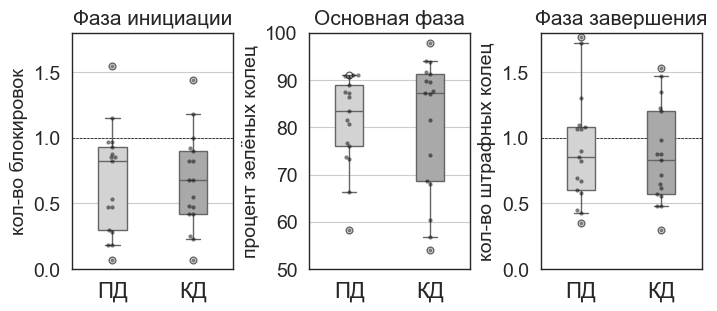

In [36]:
ylabel='lolo'
user_palette = {'MI': 'cornflowerblue', 'QM': 'salmon'}
user_palette = {'MI': '#D3D3D3', 'QM': '#A9A9A9'}


sns.set_style("white")
sns.set_context("paper", font_scale=1.2)

fig, axis = plt.subplots(1, 3, figsize=(7, 3), layout="constrained")
for i, metric in enumerate(metrics):
    ax = axis[i]
    if i == 0 or i == 2:
        ax.axhline(1, linestyle='--', color='black', linewidth=.5)
        ax.set_ylim(0, 1.8)
        ax.set_yticks(np.arange(0, 1.8, 0.5), np.arange(0, 1.8, 0.5), fontsize=14)
    else:
        ax.set_ylim(50, 100)
        ax.set_yticks(np.arange(50, 101, 10), np.arange(50, 101, 10), fontsize=14)
    sns.boxplot(df, x='condition', y=metric, width=.35, whis=(2.5, 97.5), palette=user_palette, ax=ax)
    sns.swarmplot(df, y=metric, x='condition', color='black', alpha=.5, ax=ax, s=3)
    # sns.lineplot(df, y=metric, x='condition', hue='subject', 
    #                 legend=False, palette=['grey' for _ in range(len(df))], alpha=.6, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel(ylabels[i], fontsize=14)
    ax.set_title(titles[i], fontsize=15)
    ax.set_xticks(['MI', 'QM'], ['ПД', 'КД'], fontsize=16)
    ax.grid(axis='y')
plt.savefig(r'..\data\results\pic\cognitive_conf\performance.png', dpi=300)

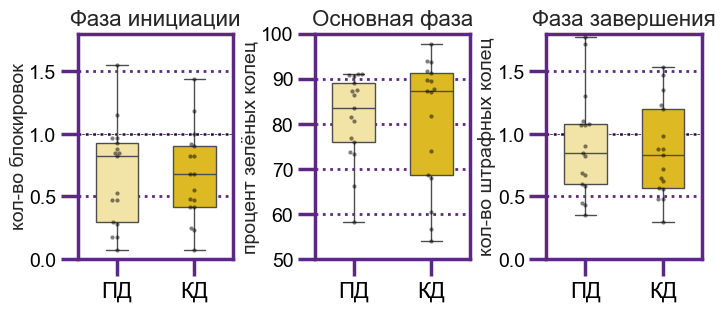

In [39]:
ylabel='lolo'
# user_palette = {'MI': 'cornflowerblue', 'QM': 'salmon'}
# user_palette = {'MI': '#D3D3D3', 'QM': '#A9A9A9'}
user_palette = {'MI': '#ffeb99', 'QM': '#fccd04'}

sns.set_style("ticks", {"grid.color": ".6", "grid.linestyle": ":",
                        'axes.edgecolor': '#5d2884', "xtick.color": "#5d2884","ytick.color": "#5d2884"})
sns.set_context("poster", font_scale=1.2)

fig, axis = plt.subplots(1, 3, figsize=(7, 3), layout="constrained")
for i, metric in enumerate(metrics):
    ax = axis[i]
    if i == 0 or i == 2:
        ax.axhline(1, linestyle='--', color='black', linewidth=.5)
        ax.set_ylim(0, 1.8)
        ax.set_yticks(np.arange(0, 1.8, 0.5), np.arange(0, 1.8, 0.5), fontsize=14, color='black')
    else:
        ax.set_ylim(50, 100)
        ax.set_yticks(np.arange(50, 101, 10), np.arange(50, 101, 10), fontsize=14, color='black')
    
    
    sns.boxplot(df, x='condition', y=metric, width=.55, whis=(0, 100), palette=user_palette, ax=ax, linewidth=1)
    sns.swarmplot(df, y=metric, x='condition', color='black', alpha=.5, ax=ax, s=3)
    # sns.lineplot(df, y=metric, x='condition', hue='subject', 
    #                 legend=False, palette=['grey' for _ in range(len(df))], alpha=.6, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel(ylabels[i], fontsize=14, labelpad=1)
    ax.set_title(titles[i], fontsize=16)
    ax.set_xticks(['MI', 'QM'], ['ПД', 'КД'], fontsize=16, color='black')
    ax.grid(axis='y', color='#5d2884')
    plt.savefig(r'C:\Users\hodor\Documents\lab-Shishkin\конференции\Когнитивная_постерная_2025\постер\pic\pic_2.png', dpi=500, bbox_inches='tight')


## plots by subject

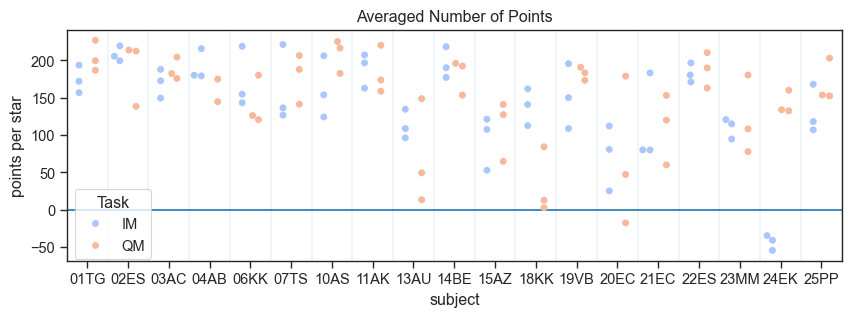

In [62]:
plt.figure(figsize=(10, 3))
metric = 'points_per_star'
# sns.boxplot(df, x='subject', y=metric, hue='condition', palette="coolwarm")
sns.swarmplot(df, x='subject', y=metric, hue='condition', dodge=True, s=5, palette="coolwarm")
# sns.swarmplot(df, x='subject', y=metric, hue='condition', dodge=True, s=5, alpha=.5, color='black', legend=False)
plt.ylabel(metric_units[metric])
plt.title(metric_names[metric])
plt.legend(title='Task', loc=[0.01, 0.01])
for i in np.arange(-0.5, 19, 1):
    plt.axvline(i, alpha=0.5, linewidth=.2)
plt.axhline(0)

Text(0.5, 1.0, 'The Initialization Phase')

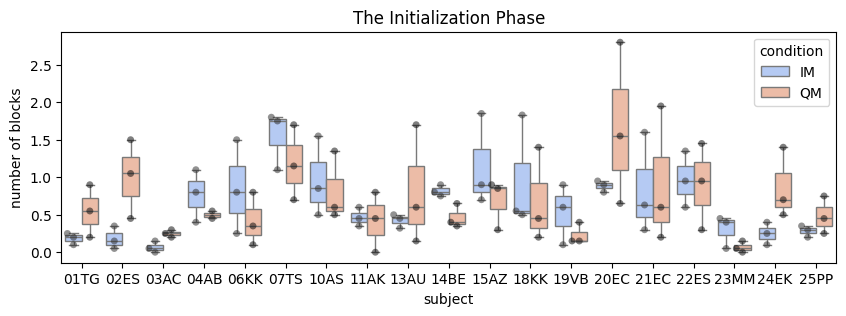

In [ ]:
plt.figure(figsize=(10, 3))
metric = 'n_hh_average'
sns.boxplot(df, x='subject', y=metric, hue='condition', palette="coolwarm")
sns.swarmplot(df, x='subject', y=metric, hue='condition', dodge=True, s=5, alpha=.5, color='black', legend=False)
plt.ylabel(metric_units[metric])
plt.title(metric_names[metric])

## plots for article

In [9]:
filename = r'..\data\results\game_metrics_per_n_game.csv'
df = pd.read_csv(filename)
df.loc[df.condition == 'im', 'condition'] = "MI"
df.loc[df.condition == 'qm', 'condition'] = "QM"
df = define_order(df, orders)
# Исключаем 04АВ, т.к. у него не записана последняя игра (3) в режиме QM к большому сожалению... 
# Исключаем 24EK, т.к. там сильно всё плохо в одном из режимов. 
df = df.loc[~df.subject.isin(['04AB', '24EK'])]

In [10]:
df.columns

Index(['total_score', 'game_duration', 'p_green_bands', 'aver_time',
       'green_steps_min', 'band_gain_min', 'n_stars', 'points_per_star',
       'n_hh_average', 'n_overkill_average', 'condition', 'n_game', 'subject',
       'order'],
      dtype='object')

In [12]:
df_artem = df[['subject', 'n_game', 'condition']+metrics]
df_artem.to_excel(r'..\data\results\game_metrics_artem.xlsx', index=False)

In [11]:
# create table with averaged across condition values
df_av = []
for subject in df.subject.unique():
    for cond in ['MI', 'QM']:
        df_curr = df.loc[(df.subject == subject) & (df.condition == cond)]
        df_average = df_curr.mean(numeric_only=True).round(3)
        df_average['absolute_score'] = df_curr['total_score'].sum()
        df_average['subject'] = subject
        df_average['condition'] = cond
        df_av.append(df_average)
df_av = pd.DataFrame(df_av)

In [18]:
def create_plot(metric, df, df_av, ax1, ax2, title, ylabel, user_palette, what_draw='boxplot'):
    sns.set_style("ticks")
    sns.set_context("paper", font_scale=1.2)
    sns.boxplot(df_av, x='condition', y=metric, width=.35, whis=(2.5, 97.5), palette=user_palette, ax=ax1)
    
    sns.swarmplot(df_av, y=metric, x='condition', color='black', alpha=.5, ax=ax1, s=3)
    sns.lineplot(df_av, y=metric, x='condition', hue='subject', 
                    legend=False, palette=['grey' for _ in range(len(df))], alpha=.6, ax=ax1)
    ax1.set_xlabel('Task')
    ax1.set_ylabel(ylabel)
    ax1.grid()
    
    legend_status = False #if not metric in  ['n_overkill_average', 'band_gain_min'] else True

    df_new = df.copy()
    #whis=(2.5, 97.5)
    if what_draw == 'boxplot':
        sns.boxplot(df_new, x='n_game', y=metric, hue='condition', whis=(0, 100), palette=user_palette, ax=ax2, legend=legend_status)
        sns.swarmplot(df_new,x='n_game', y=metric, hue='condition', dodge=True, color='black', alpha=.5, ax=ax2, s=3, legend=False)
        ax2.set_xticks([0, 1, 2], [1, 2, 3])
    else:
        df_new.loc[df_new.condition == 'MI', 'n_game'] -= 0.05
        df_new.loc[df_new.condition == 'QM', 'n_game'] += 0.05

        sns.lineplot(df_new.loc[df_new.condition == 'MI'], x='n_game', y=metric, err_style='bars', color='cornflowerblue', 
                    markers=True, style='condition', ax=ax2, estimator=np.mean, errorbar='sd', err_kws={'capsize': 5}, legend=legend_status)
        sns.lineplot(df_new.loc[df_new.condition == 'QM'], x='n_game', y=metric, err_style='bars', color='salmon',
                    markers=True, style='condition',  ax=ax2, estimator=np.mean, errorbar='sd', err_kws={'capsize': 5}, legend=legend_status)

    ax2.set_xlabel('Game')
    if legend_status:
        ax2.legend(title='Task', loc=[1.03, 0.55])
    # plt.suptitle(title, fontsize=14)
    ax2.grid()

In [ ]:
metrics = ['points_per_star', 'band_gain_min', 'n_hh_average', 'p_green_bands', 'n_overkill_average']
user_palette = {'MI': 'cornflowerblue', 'QM': 'salmon'}

for metric in metrics:
    fig, axes = plt.subplots(1, 2, figsize=(5, 3), width_ratios=[1, 1.5], sharey='row')
    create_plot(metric, df, df_av, axes[0], axes[1], 
                        metric_names[metric], metric_units[metric], user_palette, what_draw='boxplot')
    filename = os.path.join(r'..\data\results\pic\pictures\game_metrics', f'{metric_units[metric]}_boxplot.png')
    fig.savefig(filename, dpi=300,bbox_inches='tight')

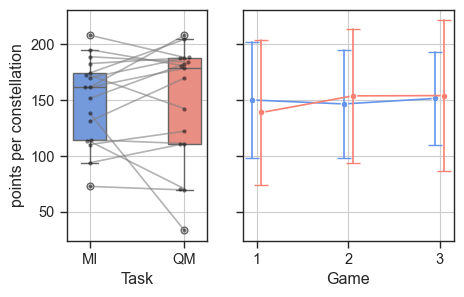

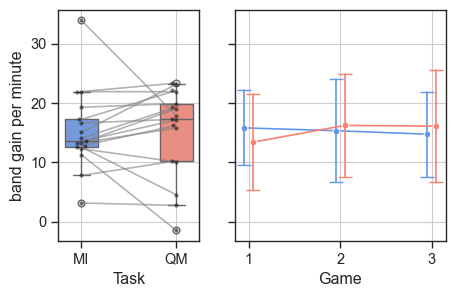

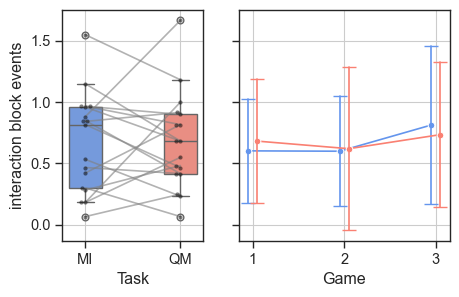

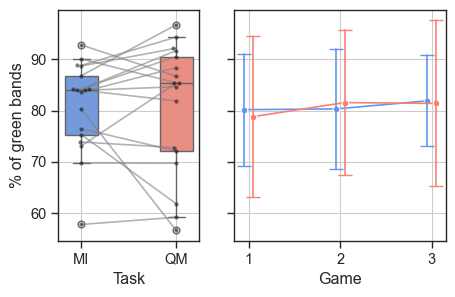

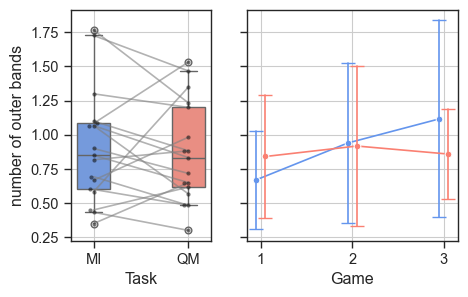

In [19]:
metrics = ['points_per_star', 'band_gain_min', 'n_hh_average', 'p_green_bands', 'n_overkill_average']
user_palette = {'MI': 'cornflowerblue', 'QM': 'salmon'}

for metric in metrics:
    fig, axes = plt.subplots(1, 2, figsize=(5, 3), width_ratios=[1, 1.5], sharey='row')
    create_plot(metric, df, df_av, axes[0], axes[1], 
            metric_names[metric], metric_units[metric], user_palette, what_draw='lineplot')
    filename = os.path.join(r'..\data\results\pic\game_metrics', f'{metric_names[metric]}_lineplot.png')
    fig.savefig(filename, dpi=300,bbox_inches='tight')

## plots for questionnaries

In [59]:
filename = r'..\data\results\questionario.xlsx'
df_surv = pd.read_excel(filename)
df_surv = pd.concat([df_surv.loc[df_surv.condition == 'MI'], df_surv.loc[df_surv.condition == 'QM']])
df_surv.head()

,subject,condition,n,attention,Difficulty,Success,TaskFit,TaskOrScreen,Auto
18,01TG,MI,1,0.646296,0.390741,0.772222,0.0,0.0,0.0
19,02ES,MI,1,0.896296,0.961111,0.953704,0.0,0.0,0.0
20,03AC,MI,1,0.744444,0.420370,0.877778,0.0,0.0,0.0
21,04AB,MI,1,0.518519,0.507407,0.905556,0.0,0.0,0.0
22,06KK,MI,1,0.670370,0.820370,0.805556,0.0,0.0,0.0


In [60]:
user_palette = {'MI': 'cornflowerblue', 'QM': 'salmon'}

### cognitive conf

In [40]:
filename = r'..\data\results\questionario.xlsx'
df_surv = pd.read_excel(filename)
df_surv = pd.concat([df_surv.loc[df_surv.condition == 'MI'], df_surv.loc[df_surv.condition == 'QM']])
df_surv.head()

,subject,condition,n,attention,Difficulty,Success,TaskFit,TaskOrScreen,Auto
18,01TG,MI,1,0.646296,0.390741,0.772222,0.0,0.0,0.0
19,02ES,MI,1,0.896296,0.961111,0.953704,0.0,0.0,0.0
20,03AC,MI,1,0.744444,0.420370,0.877778,0.0,0.0,0.0
21,04AB,MI,1,0.518519,0.507407,0.905556,0.0,0.0,0.0
22,06KK,MI,1,0.670370,0.820370,0.805556,0.0,0.0,0.0


#### тезисы

In [12]:
user_palette = {'MI': '#D3D3D3', 'QM': '#A9A9A9'}

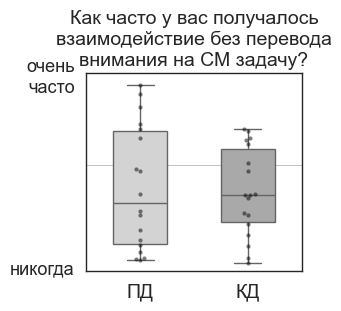

In [13]:
sns.set_style("white")
sns.set_context("paper", font_scale=1.2)

titles = ['ПД',  'КД']

fig, ax = plt.subplots(1, figsize=(3, 3), width_ratios=[1], sharey='row', layout="constrained")

df_final = df_surv.loc[df_surv.n == 3]
metric = 'Auto'
ax.axhline(0.5, color='darkgrey', linewidth=0.5)
sns.boxplot(df_final, x='condition', y=metric, whis=(0, 100),width=0.5, palette=user_palette, ax=ax)
sns.swarmplot(df_final, x='condition', y=metric, dodge=True, color='black', alpha=.5, ax=ax, s=3, legend=False)

ax.set_xticks(["MI", "QM"], titles, fontsize=14)
ax.set_yticks([0, 0.5, 0.95], ['никогда', '', 'очень\nчасто'], fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
# ax.set_title('Частота взаимодействий\nбез переключения внимания\nна СМ задачу', fontsize=14)
ax.set_title('Как часто у вас получалось\nвзаимодействие без перевода\nвнимания на СМ задачу?', fontsize=14)
# ax.grid(which='')

filename = os.path.join(r'..\data\results\pic\cognitive_conf', f'im_qm_auto.png')
fig.savefig(filename, dpi=300, bbox_inches='tight')

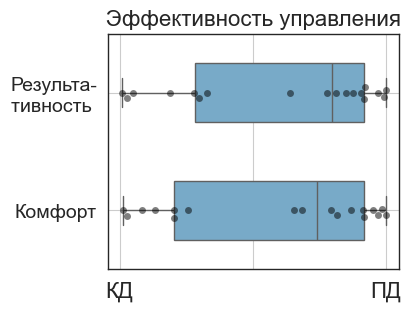

In [81]:
sns.set_style("white")
sns.set_context("paper", font_scale=1.2)

filename = r'..\data\results\questionario_final.xlsx'
df_surv_final = pd.read_excel(filename)
df_surv_final['x1'] = 0
df_surv_final['x2'] = 1

titles = ['Результа-\nтивность ',  'Комфорт']

fig, ax = plt.subplots(1, figsize=(4, 3), width_ratios=[1], sharey='row', layout="constrained")

metric = 'BetterPlay'
sns.boxplot(df_surv_final, y='x1', x=metric, whis=(0, 100),width=0.5, palette='Blues', ax=ax, orient='h')
sns.swarmplot(df_surv_final, y='x1', x=metric, dodge=True, color='black', alpha=.5, ax=ax, s=5, legend=False, orient='h')

metric = 'Comfort'
sns.boxplot(df_surv_final, y='x2', x=metric, whis=(0, 100),width=0.5, palette='Blues', ax=ax, orient='h')
sns.swarmplot(df_surv_final,y='x2', x=metric, dodge=True, color='black', alpha=.5, ax=ax, s=5, legend=False, orient='h')

ax.set_yticks([0, 1], titles, fontsize=14)
ax.set_xticks([0, 0.5, 1], ['КД', '', 'ПД'], fontsize=16)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Эффективность управления', fontsize=16)
ax.grid()
filename = os.path.join(r'..\data\results\pic\cognitive_conf', f'better_play_and_comfort.png')
fig.savefig(filename, dpi=300, bbox_inches='tight')

In [15]:
def create_plot_surv_1(metric, df, ax, title, ylabel, what_draw='boxplot'):
    sns.set_style("ticks")
    sns.set_context("paper", font_scale=1.2)

    if what_draw == 'boxplot':
        sns.boxplot(df, x='n', y=metric, whis=(0, 100), width=0.5, palette='Blues', ax=ax)
        sns.swarmplot(df,x='n', y=metric, dodge=True, color='black', alpha=.5, ax=ax, s=3, legend=False)

    else:
        df_new = df.copy()
        df_new.rename(columns={'n': 'n_game'}, inplace=True)
        df_new.loc[df_new.condition == 'MI', 'n_game'] -= 0.05 +1
        df_new.loc[df_new.condition == 'QM', 'n_game'] += 0.05 -1

        sns.lineplot(df_new, x='n_game', y=metric, err_style='bars', palette='Blues', linewidth=3,
                    markers=True, style='condition', ax=ax, estimator=np.mean, errorbar='sd', err_kws={'linewidth': 3,  'capsize': 5}, legend=False)

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([0, 1, 2], ['перед\nиграми', 'после \nигры 1', 'после \nигры 3'], fontsize=12)
    ax.set_title(title, fontsize=14)
    if df['condition'].unique() == 'QM':
        ax.set_yticks([0, .5, 1], ['постоянно', '', 'никогда'], fontsize=12)
        ax.set_ylim((-0.05, 1.05)[::-1])
    else:
        ax.set_yticks([0, .5, 1], ['блеклый', '', 'очень\nяркий'], fontsize=12)
        ax.set_ylim((-0.05, 1.05))
    
    # plt.suptitle(title, fontsize=14)
    ax.grid()

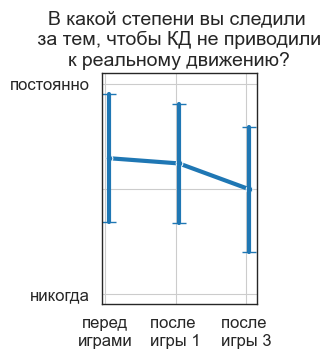

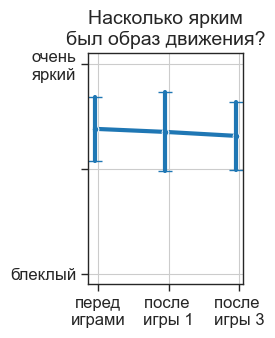

In [16]:
metrics = ['attention', 'attention']
titles = ['В какой степени вы следили \n за тем, чтобы КД не приводили \nк реальному движению?',  'Насколько ярким\nбыл образ движения?']
ylabels = ['',  '']

for i in range(len(metrics)):
    fig, axis = plt.subplots(1, figsize=(2, 3), width_ratios=[1], sharey='row')
    mode = 'QM' if i == 0 else 'MI'
    create_plot_surv_1(metrics[i], df_surv.loc[df_surv.condition == mode], axis, titles[i], ylabels[i], 'lineplot')
    filename = os.path.join(r'..\data\results\pic\cognitive_conf', f'{mode}.png')
    fig.savefig(filename, dpi=300,bbox_inches='tight')

#### постер

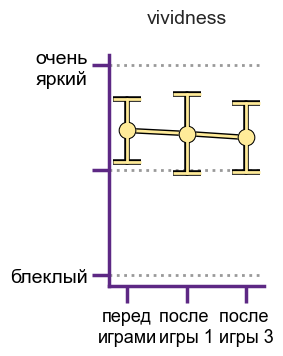

In [45]:
sns.set_style("ticks", {"grid.color": ".6", "grid.linestyle": ":",
                        'axes.edgecolor': '#5d2884', "xtick.color": "#5d2884","ytick.color": "#5d2884"})
sns.set_context("poster", font_scale=1.2)
# yellow fccd04
fig, ax = plt.subplots(1, figsize=(2, 3), sharey='row')

mode = 'MI'
df_new = df_surv.loc[df_surv.condition == mode].copy()
df_new.rename(columns={'n': 'n_game'}, inplace=True)
df_new.loc[df_new.condition == 'MI', 'n_game'] -= +1
df_new.loc[df_new.condition == 'QM', 'n_game'] +=  -1

sns.lineplot(df_new, x='n_game', y='attention', err_style='bars', color='black', linewidth=4,
            markers=True, style='condition', ax=ax, estimator=np.mean, errorbar='sd', 
            err_kws={'linewidth': 4,  'capsize': 10, 'capthick': 4}, legend=False, zorder=1)

sns.lineplot(df_new, x='n_game', y='attention', err_style='bars', color='#ffeb99', linewidth=2,
            markers=True, style='condition', ax=ax, estimator=np.mean, errorbar='sd', 
            err_kws={'linewidth': 2,  'capsize': 10, 'capthick': 2}, legend=False, zorder=2,
            markerfacecolor='#ffeb99', markeredgecolor='black')

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([0, 1, 2], ['перед\nиграми', 'после \nигры 1', 'после \nигры 3'], fontsize=13, color='black')
ax.set_xlim((-0.3, 2.3))
ax.set_title('vividness', fontsize=14, y=1.1)

ax.set_yticks([0, .5, 1], ['блеклый', '', 'очень\nяркий'], fontsize=14, color='black')
ax.set_ylim((-0.05, 1.05))

ax.grid(axis='y')
sns.despine()
fig.show()
plt.savefig(r'C:\Users\hodor\Documents\lab-Shishkin\конференции\Когнитивная_постерная_2025\постер\pic\pic_5.png', dpi=500, bbox_inches='tight')

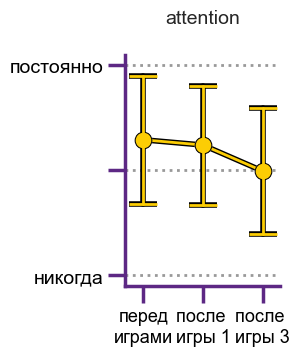

In [46]:
sns.set_style("ticks", {"grid.color": ".6", "grid.linestyle": ":",
                        'axes.edgecolor': '#5d2884', "xtick.color": "#5d2884","ytick.color": "#5d2884"})
sns.set_context("poster", font_scale=1.2)
# yellow fccd04
fig, ax = plt.subplots(1, figsize=(2, 3), sharey='row')

mode = 'QM'
df_new = df_surv.loc[df_surv.condition == mode].copy()
df_new.rename(columns={'n': 'n_game'}, inplace=True)
df_new.loc[df_new.condition == 'MI', 'n_game'] -= +1
df_new.loc[df_new.condition == 'QM', 'n_game'] +=  -1

sns.lineplot(df_new, x='n_game', y='attention', err_style='bars', color='black', linewidth=4,
            markers=True, style='condition', ax=ax, estimator=np.mean, errorbar='sd', 
            err_kws={'linewidth': 4,  'capsize': 10, 'capthick': 4}, legend=False, zorder=1)

sns.lineplot(df_new, x='n_game', y='attention', err_style='bars', color='#fccd04', linewidth=2,
            markers=True, style='condition', ax=ax, estimator=np.mean, errorbar='sd', 
            err_kws={'linewidth': 2,  'capsize': 10, 'capthick': 2}, legend=False, zorder=2,
            markerfacecolor='#fccd04', markeredgecolor='black')

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([0, 1, 2], ['перед\nиграми', 'после \nигры 1', 'после \nигры 3'], fontsize=13, color='black')
ax.set_xlim((-0.3, 2.3))
ax.set_title('attention', fontsize=14, y=1.1)

ax.set_yticks([0, .5, 1], ['постоянно', '', 'никогда'], fontsize=14, color='black')
ax.set_ylim((-0.05, 1.05)[::-1])

ax.grid(axis='y')
sns.despine()
fig.show()
plt.savefig(r'C:\Users\hodor\Documents\lab-Shishkin\конференции\Когнитивная_постерная_2025\постер\pic\pic_6.png', dpi=500, bbox_inches='tight')

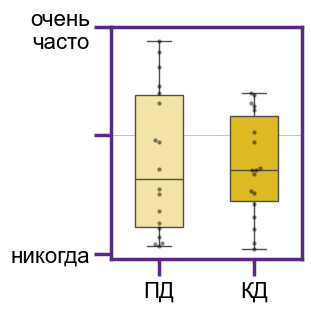

In [47]:
user_palette = {'MI': '#ffeb99', 'QM': '#fccd04'}

sns.set_style("ticks", {"grid.color": ".6", "grid.linestyle": ":",
                        'axes.edgecolor': '#5d2884', "xtick.color": "#5d2884","ytick.color": "#5d2884"})
sns.set_context("poster", font_scale=1.2)

titles = ['ПД',  'КД']

fig, ax = plt.subplots(1, figsize=(3, 3), width_ratios=[1], sharey='row', layout="constrained")

df_final = df_surv.loc[df_surv.n == 3]
metric = 'Auto'
ax.axhline(0.5, color='darkgrey', linewidth=0.5)
sns.boxplot(df_final, x='condition', y=metric, whis=(0, 100),width=0.5, palette=user_palette, ax=ax)
sns.swarmplot(df_final, x='condition', y=metric, dodge=True, color='black', alpha=.5, ax=ax, s=3, legend=False)

ax.set_xticks(["MI", "QM"], titles,  fontsize=16, color='black')
ax.set_yticks([0, 0.5, 0.95], ['никогда', '', 'очень\nчасто'], fontsize=16, color='black')
ax.set_xlabel('')
ax.set_ylabel('')
# ax.set_title('Частота взаимодействий\nбез переключения внимания\nна СМ задачу', fontsize=14)
# ax.set_title('Как часто у вас получалось\nвзаимодействие без перевода\nвнимания на СМ задачу?', fontsize=14, y=1.5)
# ax.grid(which='')

# filename = os.path.join(r'..\data\results\pic\cognitive_conf', f'im_qm_auto.png')
# fig.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(r'C:\Users\hodor\Documents\lab-Shishkin\конференции\Когнитивная_постерная_2025\постер\pic\pic_7.png', dpi=500, bbox_inches='tight')

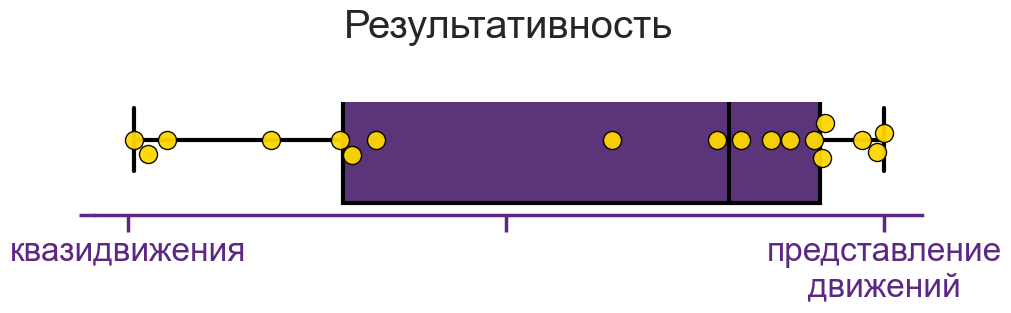

In [44]:
sns.set_style("ticks", {'axes.edgecolor': '#5d2884', "xtick.color": "#5d2884","ytick.color": "#5d2884"})
sns.set_context("poster", font_scale=1.2)

filename = r'..\data\results\questionario_final.xlsx'
df_surv_final = pd.read_excel(filename)
df_surv_final['x1'] = 0
df_surv_final['x2'] = 1

titles = ['Результа-\nтивность ',  'Комфорт']

fig, ax = plt.subplots(1, figsize=(10, 3),  sharey='row', layout="constrained")

metric = 'BetterPlay'
sns.boxplot(df_surv_final, y='x1', x=metric, whis=(0, 100), width=1.7, 
            linewidth=3, linecolor='#000000',
            color='#5d2884', ax=ax, orient='h')
sns.swarmplot(df_surv_final, y='x1', x=metric, dodge=True, color='gold', alpha=.95, 
              linewidth=1, edgecolor='black',
              ax=ax, s=13, legend=False, orient='h')
ax.set_yticks('')
ax.set_xticks([0, 0.5, 1], ['квазидвижения', '', 'представление\nдвижений'], fontsize=24)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Результативность', y=1.5)
sns.despine(left=True)
plt.savefig(r'C:\Users\hodor\Documents\lab-Shishkin\конференции\Когнитивная_постерная_2025\постер\pic\pic_3.png', dpi=500, bbox_inches='tight')

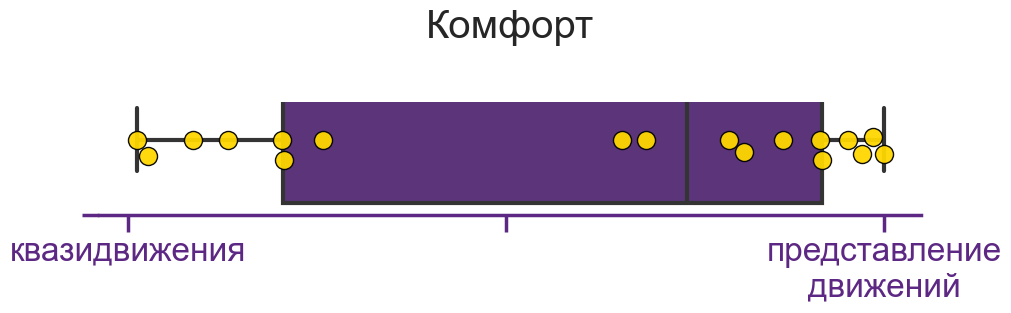

In [43]:
sns.set_style("ticks", {'axes.edgecolor': '#5d2884', "xtick.color": "#5d2884","ytick.color": "#5d2884"})
sns.set_context("poster", font_scale=1.2)

filename = r'..\data\results\questionario_final.xlsx'
df_surv_final = pd.read_excel(filename)
df_surv_final['x1'] = 0
df_surv_final['x2'] = 1


fig, ax = plt.subplots(1, figsize=(10, 3), width_ratios=[1], sharey='row', layout="constrained")

metric = 'Comfort'
sns.boxplot(df_surv_final, y='x1', x=metric, whis=(0, 100), width=1.7, 
            linewidth=3, 
            color='#5d2884', ax=ax, orient='h')
sns.swarmplot(df_surv_final, y='x1', x=metric, dodge=True, color='gold', alpha=.95, 
              linewidth=1, edgecolor='black',
              ax=ax, s=13, legend=False, orient='h')
ax.set_yticks('')
ax.set_xticks([0, 0.5, 1], ['квазидвижения', '', 'представление\nдвижений'], fontsize=24)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Комфорт', y=1.5)
sns.despine(left=True)
plt.savefig(r'C:\Users\hodor\Documents\lab-Shishkin\конференции\Когнитивная_постерная_2025\постер\pic\pic_4.png', dpi=500, bbox_inches='tight')

In [ ]:
sns.set_style("white")
sns.set_context("paper", font_scale=1.2)

filename = r'..\data\results\questionario_final.xlsx'
df_surv_final = pd.read_excel(filename)
df_surv_final['x1'] = 0
df_surv_final['x2'] = 1

titles = ['Результа-\nтивность ',  'Комфорт']

fig, ax = plt.subplots(1, figsize=(4, 3), width_ratios=[1], sharey='row', layout="constrained")

metric = 'BetterPlay'
sns.boxplot(df_surv_final, y='x1', x=metric, whis=(0, 100),width=0.5, palette='Blues', ax=ax, orient='h')
sns.swarmplot(df_surv_final, y='x1', x=metric, dodge=True, color='black', alpha=.5, ax=ax, s=5, legend=False, orient='h')

metric = 'Comfort'
sns.boxplot(df_surv_final, y='x2', x=metric, whis=(0, 100),width=0.5, palette='Blues', ax=ax, orient='h')
sns.swarmplot(df_surv_final,y='x2', x=metric, dodge=True, color='black', alpha=.5, ax=ax, s=5, legend=False, orient='h')

ax.set_yticks([0, 1], titles, fontsize=14)
ax.set_xticks([0, 0.5, 1], ['КД', '', 'ПД'], fontsize=16)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Эффективность управления', fontsize=16)
ax.grid()
# filename = os.path.join(r'..\data\results\pic\cognitive_conf', f'better_play_and_comfort.png')
# fig.savefig(filename, dpi=300, bbox_inches='tight')

### ability & difficulty

In [11]:
def create_plot_surv(metric, df, ax, title, ylabel, legend_status, user_palette, what_draw='boxplot'):
    sns.set_style("ticks")
    sns.set_context("paper", font_scale=1.2)

    if what_draw == 'boxplot':
        sns.boxplot(df, x='n', y=metric, hue='condition', whis=(0, 100), palette=user_palette, ax=ax, legend=legend_status)
        sns.swarmplot(df,x='n', y=metric, hue='condition', dodge=True, color='black', alpha=.5, ax=ax, s=3, legend=False)
    else:
        df_new = df.copy()
        df_new.rename(columns={'n': 'n_game'}, inplace=True)
        df_new.loc[df_new.condition == 'MI', 'n_game'] -= 0.05 + 1
        df_new.loc[df_new.condition == 'QM', 'n_game'] += 0.05 -1 

        sns.lineplot(df_new.loc[df_new.condition == 'MI'], x='n_game', y=metric, err_style='bars', color='cornflowerblue', 
                    markers=True, style='condition', ax=ax, estimator=np.mean, errorbar='sd', err_kws={'capsize': 5}, legend=legend_status)
        sns.lineplot(df_new.loc[df_new.condition == 'QM'], x='n_game', y=metric, err_style='bars', color='salmon',
                    markers=True, style='condition',  ax=ax, estimator=np.mean, errorbar='sd', err_kws={'capsize': 5}, legend=legend_status)

    if metric == 'n_hh_average':
        ax.hlines(2.0, 1.2, 2.2, color='k', alpha=.5)
        ax.set_ylim(-0.1, 2.3)
        ax.text(s='p < 0.5', x=1.35, y=2.07, fontsize=8)
    ax.set_xlabel('')
    ax.set_xticks([0, 1, 2], ['before\ngames', 'after  \ngame 1', 'after  \ngame 3'])
    ax.set_ylabel(title)
    ax.set_ylim(-0.05, 1.05)
    
    # if metric == 'n_overkill_average' or metric == ''
    if legend_status:
        ax.legend(title='Task', loc=[1.03, 0.55])
    # plt.suptitle(title,  fontsize=14)
    ax.grid()

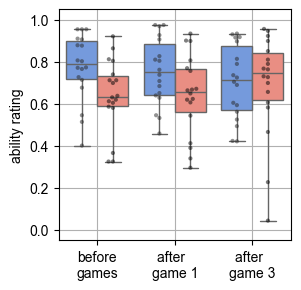

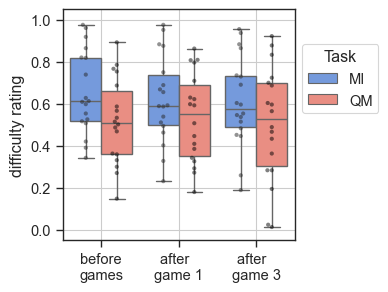

In [12]:
metrics = ['Success', 'Difficulty']
titles = ['ability rating',  'difficulty rating']
ylabels = ['',  '']

for i in range(len(metrics)):
    fig, axis = plt.subplots(1, figsize=(3, 3), width_ratios=[1], sharey='row')
    legend_status = True if metrics[i] == 'Difficulty' else False
    create_plot_surv(metrics[i], df_surv, axis, titles[i], ylabels[i], legend_status, user_palette, what_draw='boxplot')
    filename = os.path.join(r'..\data\results\pic\pictures\surv_metrics', f'{titles[i]}_boxplot.png')
    fig.savefig(filename, dpi=300,bbox_inches='tight')

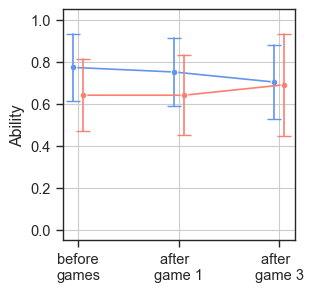

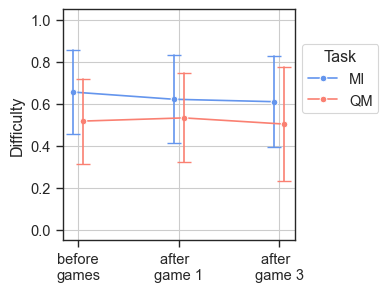

In [30]:
metrics = ['Success', 'Difficulty']
titles = ['Ability',  'Difficulty']

ylabels = ['',  '']

for i in range(len(metrics)):
    fig, axis = plt.subplots(1, figsize=(3, 3), width_ratios=[1], sharey='row')
    legend_status = True if metrics[i] == 'Difficulty' else False
    create_plot_surv(metrics[i], df_surv, axis, titles[i], ylabels[i], legend_status, user_palette, what_draw='lineplot')
    filename = os.path.join(r'..\data\results\pic\surv_metrics', f'{titles[i]}_lineplot.png')
    fig.savefig(filename, dpi=300,bbox_inches='tight')

### Amplitude Attention & Vividness

In [13]:
def create_plot_surv_1(metric, df, ax, title, ylabel, user_palette, what_draw='boxplot'):
    sns.set_style("ticks")
    sns.set_context("paper", font_scale=1.2)

    if what_draw == 'boxplot':
        sns.boxplot(df, x='n', y=metric, whis=(0, 100), width=0.5, color=user_palette[df.condition.unique()[0]], ax=ax)
        sns.swarmplot(df,x='n', y=metric, dodge=True, color='black', alpha=.5, ax=ax, s=3, legend=False)

    else:
        df_new = df.copy()
        df_new.rename(columns={'n': 'n_game'}, inplace=True)
        df_new.loc[df_new.condition == 'MI', 'n_game'] -= 0.05 +1
        df_new.loc[df_new.condition == 'QM', 'n_game'] += 0.05 -1

        sns.lineplot(df_new, x='n_game', y=metric, err_style='bars', color=user_palette[df.condition.unique()[0]], 
                    markers=True, style='condition', ax=ax, estimator=np.mean, errorbar='sd', err_kws={'capsize': 5}, legend=False)

    ax.set_xlabel('')
    ax.set_xticks([0, 1, 2], ['before\ngames', 'after  \ngame 1', 'after  \ngame 3'])
    ax.set_ylabel(title)
    ax.set_ylim(-0.05, 1.05)
    
    # plt.suptitle(title, fontsize=14)
    ax.grid()

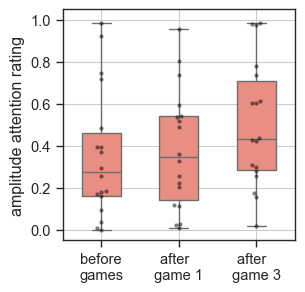

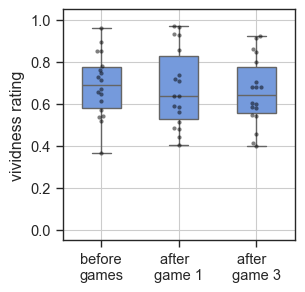

In [200]:
metrics = ['attention', 'attention']
titles = ['amplitude attention rating',  'vividness rating']
ylabels = ['',  '']

for i in range(len(metrics)):
    fig, axis = plt.subplots(1, figsize=(3, 3), width_ratios=[1], sharey='row')
    mode = 'QM' if i == 0 else 'MI'
    create_plot_surv_1(metrics[i], df_surv.loc[df_surv.condition == mode], axis, titles[i], ylabels[i], user_palette)
    filename = os.path.join(r'..\data\results\pic\pictures\surv_metrics', f'{titles[i]}_boxplot.png')
    fig.savefig(filename, dpi=300,bbox_inches='tight')

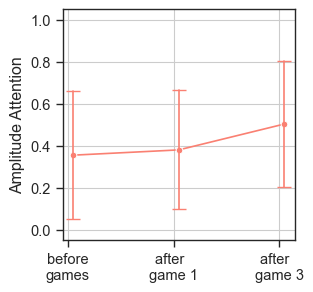

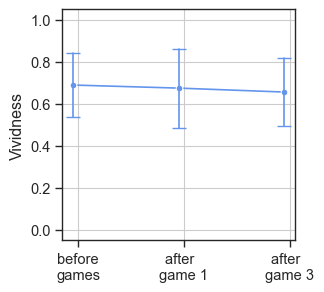

In [14]:
metrics = ['attention', 'attention']
titles = ['Amplitude Attention',  'Vividness']
ylabels = ['',  '']

for i in range(len(metrics)):
    fig, axis = plt.subplots(1, figsize=(3, 3), width_ratios=[1], sharey='row')
    mode = 'QM' if i == 0 else 'MI'
    create_plot_surv_1(metrics[i], df_surv.loc[df_surv.condition == mode], axis, titles[i], ylabels[i], user_palette, 'lineplot')
    filename = os.path.join(r'..\data\results\pic\surv_metrics', f'{titles[i]}_lineplot.png')
    fig.savefig(filename, dpi=300,bbox_inches='tight')

### Auto & Task Suitability & Focus

In [66]:
def create_plot_surv_2(metric, df, ax, title, ylabel, palette):
    sns.set_style("ticks")
    sns.set_context("paper", font_scale=1.2)

    sns.boxplot(df, x='condition', y=metric, whis=(0, 100),width=0.35, palette=palette, ax=ax)
    sns.swarmplot(df, x='condition', y=metric, dodge=True, color='black', alpha=.5, ax=ax, s=3, legend=False)

    # Добавим среднее и стандартное отклонение вручную
    group_stats = df.groupby('condition')[metric].agg(['mean', 'std']).reset_index()
    for i, row in group_stats.iterrows():
        sns.swarmplot(x=[row['condition']], y=[row['mean']], color='yellow', s=5, marker='D', ax=ax)
        # ax.errorbar(x=i+.35, y=row['mean'], yerr=row['std'],
        #             fmt='o', color='red' if i==1 else 'blue', capsize=5, label='mean±std' if i == 0 else "")

    if title == 'Amplitude Attention':
        ax.hlines(1.1, 0, 2, color='k', alpha=.5)
        ax.set_ylim(-0.05, 1.25)
        ax.text(s='p = 0.001', x=0.6, y=1.14, fontsize=8)
    else:
        ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Task')
    ax.set_ylabel(title)
    
    # if metric == 'n_overkill_average' or metric == ''
    # ax.legend(title='Task', loc=[1.03, 0.55])
    # plt.suptitle(title, fontsize=14)
    ax.grid()

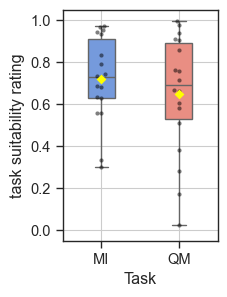

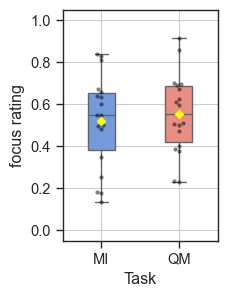

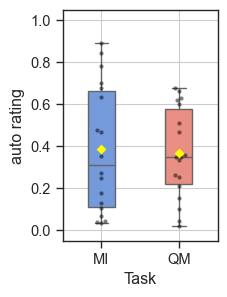

In [67]:
metrics = ['TaskFit', 'TaskOrScreen', 'Auto']
titles = ['task suitability rating',  'focus rating', 'auto rating']
ylabels = ['',  '', '']

for i in range(len(metrics)):
    fig, axis = plt.subplots(1, figsize=(2, 3), width_ratios=[1], sharey='row')
    # mode = 'qm' if i == 0 else 'im'
    # color = '#ecbca7' if i == 0 else '#b5caf3'
    create_plot_surv_2(metrics[i], df_surv.loc[df_surv.n == 3], axis, titles[i], ylabels[i], palette=user_palette)
    filename = os.path.join(r'..\data\results\pic\surv_metrics', f'{titles[i]}.png')
    fig.savefig(filename, dpi=300,bbox_inches='tight')

### better play & comfort

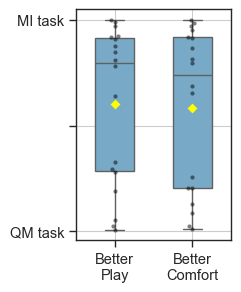

In [84]:
filename = r'..\data\results\questionario_final.xlsx'
df_surv_final = pd.read_excel(filename)
df_surv_final['x1'] = 0
df_surv_final['x2'] = 1

titles = ['Better\nPlay',  'Better\nComfort']

fig, ax = plt.subplots(1, figsize=(2, 3), width_ratios=[1], sharey='row')
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)

metric = 'BetterPlay'
sns.boxplot(df_surv_final, x='x1', y=metric, whis=(0, 100),width=0.5, palette='Blues', ax=ax)
sns.swarmplot(df_surv_final, x='x1', y=metric, dodge=True, color='black', alpha=.5, ax=ax, s=3, legend=False)
# Добавим среднее и стандартное отклонение вручную
m = df_surv_final[metric].mean()
sns.swarmplot(x=0, y=[m], color='yellow', s=5, marker='D', ax=ax)

metric = 'Comfort'
sns.boxplot(df_surv_final, x='x2', y=metric, whis=(0, 100),width=0.5, palette='Blues', ax=ax)
sns.swarmplot(df_surv_final, x='x2', y=metric, dodge=True, color='black', alpha=.5, ax=ax, s=3, legend=False)
# Добавим среднее и стандартное отклонение вручную
m = df_surv_final[metric].mean()
sns.swarmplot(x=1, y=[m], color='yellow', s=5, marker='D', ax=ax)

ax.set_xticks([0, 1], titles)
ax.set_yticks([0, 0.5, 1], ['QM task', '', 'MI task'])
ax.set_xlabel('')
ax.set_ylabel('')

# if metric == 'n_overkill_average' or metric == ''
# ax.legend(title='Task', loc=[1.03, 0.55])
# plt.suptitle(title, y=1.02, fontsize=14)
ax.grid()
filename = os.path.join(r'..\data\results\pic\surv_metrics', f'better_play_and_comfort.png')
fig.savefig(filename, dpi=300,bbox_inches='tight')

### nasa

In [74]:
filename = r'..\data\results\nasa_sus.xlsx'
df_ques = pd.read_excel(filename)
df_ques.head()

,subject,condition,NasaMentalDemand,NasaPhysDemand,NasaTempDemand,NasaPerformance,NasaEffort,NasaFrustration,SUS_Like,SUS_Complex,SUS_Easy,SUS_Help,SUS_Integr,SUS_Inconsist,SUS_LearnQuick,SUS_Cumbersome,SUS_Confidence,SUS_LearnCurve
0,01TG,QM,0.788288,0.780781,0.141141,0.552553,0.551051,0.153153,3,0,3,0,4,0,3,1,3,1
1,02ES,QM,0.154655,0.650150,0.034535,0.996997,1.000000,1.000000,0,3,0,4,0,4,0,4,0,2
2,03AC,QM,0.854354,0.701201,0.396396,0.144144,0.843844,0.551051,3,2,2,1,4,0,3,2,2,3
3,04AB,QM,0.340841,0.055556,0.202703,0.813814,0.728228,0.728228,0,2,0,3,2,3,0,4,0,2
4,06KK,QM,0.187688,0.064565,0.671171,0.226727,0.653153,0.351351,0,0,2,0,3,1,4,0,3,0


In [75]:
nasa_metrics = [metric for metric in df_ques.columns.to_list() if metric.find("Nasa") != -1]
sus_metrics = [metric for metric in df_ques.columns.to_list() if metric.find("SUS") != -1]

In [76]:
nasa_titles = ['Mental\nDemand', 'Physical\nDemand', 'Temporal\nDemand', 'Performance', 'Effort', 'Frustraion']
sus_titles = ['HighUse\nFreq', 'SysToo\nCompl', 'SysEasy\nToUse', 'Need\nTech\nSupport', 'Func\nIntegr\nWell', 'Incons\nSys', 'Learn\nQuick', 'Cumber\nToUse', 'Confid\nInUse', 'NeedTo\nLearn']

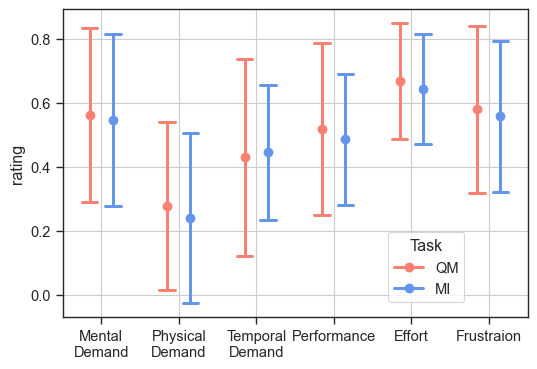

In [82]:
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
plt.figure(figsize=(6, 4))
for i, metric in enumerate(nasa_metrics):
    df_ques[f'x_{metric}'] = i
    legend_status = True if i == 0 else False
    # sns.boxplot(df_ques, x =f'x_{metric}',  y=metric, hue='condition', palette=user_palette, legend=legend_status)
    # sns.swarmplot(df_ques, x =f'x_{metric}',  y=metric, hue='condition', dodge=True, color='black', alpha=.5, s=3, legend=False)

    # df_new = df.copy()
    # df_new.rename(columns={'n': 'n_game'}, inplace=True)
    # df_new.loc[df_new.condition == 'MI', 'n_game'] -= 0.05 +1
    # df_new.loc[df_new.condition == 'QM', 'n_game'] += 0.05 -1

    sns.pointplot(df_ques,  x =f'x_{metric}', y=metric, hue='condition', palette=user_palette, legend=legend_status,
                estimator=np.mean, errorbar='sd', dodge=.3, capsize=.2)
    
plt.legend(loc=[0.7, 0.05], title='Task')
plt.xticks(np.arange(len(nasa_metrics)), nasa_titles);
plt.grid()
plt.ylabel('rating')
plt.xlabel('')
filename = os.path.join(r'..\data\results\pic\surv_metrics', f'nasa_lineplot.png')
plt.savefig(filename, dpi=300,bbox_inches='tight')

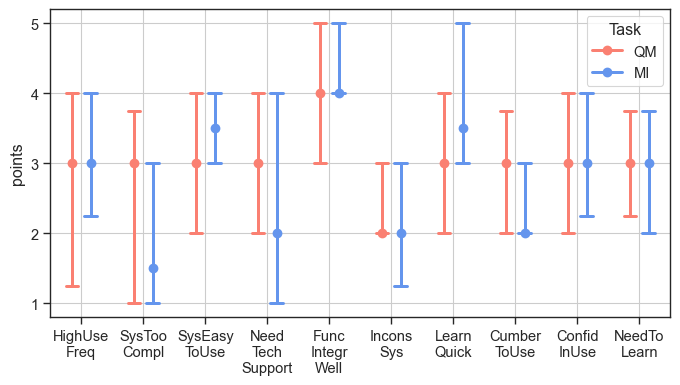

In [83]:
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
plt.figure(figsize=(8, 4))
for i, metric in enumerate(sus_metrics):
    df_ques[f'x_{metric}'] = i
    legend_status = True if i == 0 else False
    # sns.pointplot(df_ques,  x =f'x_{metric}', y=metric, hue='condition', palette=user_palette, legend=legend_status,
    #             estimator=np.mean, errorbar='sd', dodge=.3, capsize=.2)
    sns.pointplot(df_ques,  x =f'x_{metric}', y=metric, hue='condition', palette=user_palette, legend=legend_status,
                estimator=np.median, errorbar=('pi', 50), dodge=.3, capsize=.2)
    # sns.boxplot(df_ques, x =f'x_{metric}',  y=metric, hue='condition', palette=user_palette, legend=legend_status)
    # sns.swarmplot(df_ques, x =f'x_{metric}',  y=metric, hue='condition', dodge=True, color='black', alpha=.5, s=3, legend=False)
plt.legend(title='Task')
plt.xticks(np.arange(len(sus_metrics)), sus_titles);
plt.yticks(np.arange(5), np.arange(1, 6))
plt.grid()
plt.ylabel('points')
plt.xlabel('')
filename = os.path.join(r'..\data\results\pic\surv_metrics', f'sus_lineplot.png')
plt.savefig(filename, dpi=300,bbox_inches='tight')

# accuracies per bands

In [9]:
filename = r'..\data\results\game_dataset.csv'
df = pd.read_csv(filename)
df.rename(columns={'mode': 'condition'}, inplace=True)

In [10]:
df_band = df.loc[df.event.isin([f'blast_step_{i}' for i in range(1, 9)] + ['overkill_step'])]
df_new = []
for subject in df.subject.unique():
    for cond in ['im', 'qm']:
        for n_game in df_band.loc[(df_band.subject == subject) & (df_band.condition == cond)]['n_game'].unique():
            for n_star in df_band.loc[(df_band.subject == subject) & (df_band.condition == cond) & (df_band.n_game == n_game)]['n_star'].unique():
                df_star_all = df_band.loc[(df_band.subject == subject) & (df_band.condition == cond) & (df_band.n_game == n_game) & (df_band.n_star == n_star)].copy()
                for filename in df_star_all.filename.unique():
                    df_star = df_star_all.loc[df_star_all.filename == filename]
                    n_overkill = 0
                    n_band = 0
                    for event in df_star.event.values:
                        ev = df_star.loc[df_star.event == event]
                        if event == 'overkill_step':
                            n_overkill += 1
                            event_name = f'outer_band_{n_overkill}'
                            decision = 0 if ev['decision'].values[0] == 'no_overkill' else 1
                        else:
                            n_band += 1
                            event_name = f'inner_band_{n_band}'
                            decision = 1 if ev['decision'].values[0] == 'success' else 0
                        new_event = {}
                        new_event['event_name'] = event_name
                        new_event['decision'] = decision
                        for name in ['subject', 'condition', 'res_timestamp', 'n_star', 'n_game', 'filename']:
                            new_event[name] = ev[name].values[0]
                        df_new.append(new_event)
                    if n_overkill < 4:
                        while n_overkill < 4:
                            n_overkill += 1
                            new_event = {}
                            new_event['event_name'] = f'outer_band_{n_overkill}'
                            new_event['decision'] = 0
                            for name in ['subject', 'condition', 'res_timestamp', 'n_star', 'n_game', 'filename']:
                                new_event[name] = ev[name].values[0]
                            df_new.append(new_event)  

In [11]:
df_band = pd.DataFrame(df_new)

In [12]:
df_new = []
for event in [f'inner_band_{i}' for i in range(1, 9)] + [f'outer_band_{i}' for i in range(1, 5)]:
    df_new.append(df_band.loc[df_band.event_name == event].copy())
df_band = pd.concat(df_new, ignore_index=True)

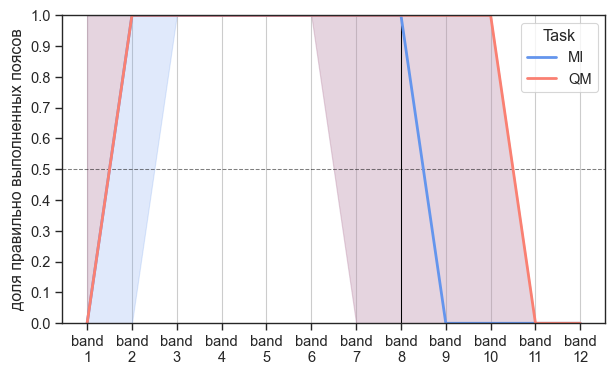

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
user_palette = {'im': 'cornflowerblue', 'qm': 'salmon'}
plt.axvline(7, linewidth=.75, color='black')
plt.axhline(.5, linewidth=.75, color='black', linestyle='--', alpha=.5)
sns.lineplot(df_band, x='event_name', y='decision', hue='condition', estimator=np.median, errorbar=('pi', 50), palette=user_palette, linewidth=2)
plt.ylabel('доля правильно выполненных поясов')
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel('')
plt.grid(axis='x')
plt.xticks(df_band.event_name.unique(), [f'band\n{i}' for i in range(1, 13)]);
plt.legend(ax.get_legend().legend_handles, ['MI', 'QM'], title='Task')

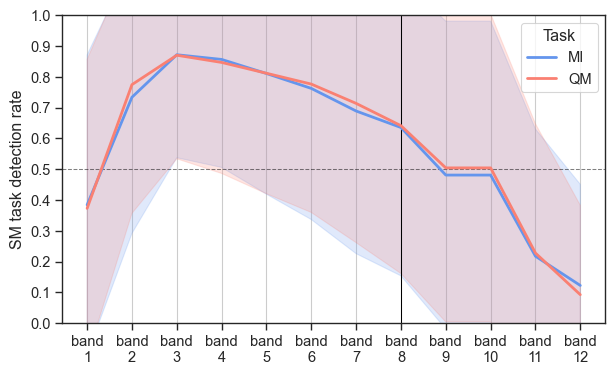

In [63]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
user_palette = {'im': 'cornflowerblue', 'qm': 'salmon'}
plt.axvline(7, linewidth=.75, color='black')
plt.axhline(.5, linewidth=.75, color='black', linestyle='--', alpha=.5)
sns.lineplot(df_band, x='event_name', y='decision', hue='condition', estimator=np.mean, errorbar=('sd', 1), palette=user_palette, linewidth=2)
plt.ylabel('SM task detection rate')
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel('')
plt.grid(axis='x')
plt.xticks(df_band.event_name.unique(), [f'band\n{i}' for i in range(1, 13)]);
plt.legend(ax.get_legend().legend_handles, ['MI', 'QM'], title='Task')

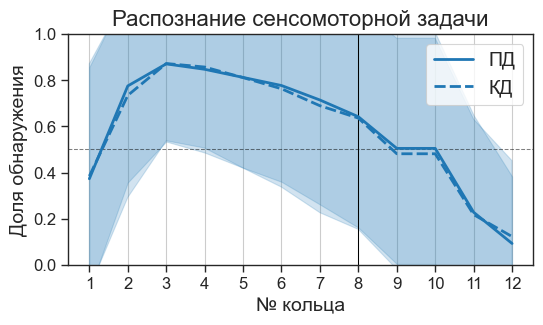

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
user_palette = {'im': '#D3D3D3', 'qm': '#A9A9A9'}
plt.axvline(7, linewidth=.75, color='black')
plt.axhline(.5, linewidth=.75, color='black', linestyle='--', alpha=.5)
sns.lineplot(df_band, x='event_name', y='decision', style='condition', style_order=[ 'qm','im'], estimator=np.mean, errorbar=('sd', 1), palette=user_palette, linewidth=2)
plt.ylabel('Доля обнаружения', fontsize=14)
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.2).round(2), np.arange(0, 1.1, 0.2).round(2), fontsize=12)
plt.xlabel('№ кольца', fontsize=14)
plt.title('Распознание сенсомоторной задачи', fontsize=16)
plt.grid(axis='x')
# plt.xticks(df_band.event_name.unique(), [f'band\n{i}' for i in range(1, 13)]);
plt.xticks(df_band.event_name.unique(), range(1, 13), fontsize=12);
plt.legend(ax.get_legend().legend_handles, ['ПД', 'КД'], fontsize=14)
# plt.savefig(r'..\data\results\pic\cognitive_conf\accuracy.png', dpi=300,bbox_inches='tight')

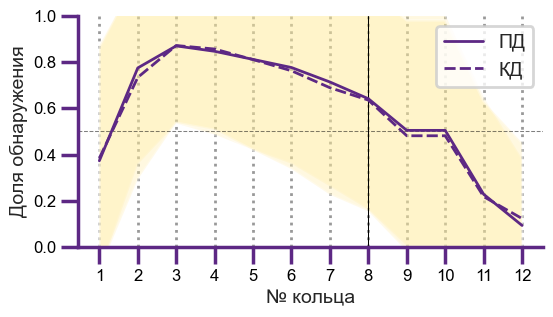

In [33]:
sns.set_style("ticks", {"grid.color": ".6", "grid.linestyle": ":",
                        'axes.edgecolor': '#5d2884', "xtick.color": "#5d2884","ytick.color": "#5d2884"})
sns.set_context("poster", font_scale=1.2)
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

user_palette = {'im': '#ffeb99', 'qm': '#fccd04'}
plt.axvline(7, linewidth=.75, color='black')
plt.axhline(.5, linewidth=.75, color='black', linestyle='--', alpha=.5)
sns.lineplot(df_band, x='event_name', y='decision', style='condition',  style_order=['qm','im'], 
             estimator=np.mean, errorbar=('sd', 1), err_kws={'alpha': 0.3, 'facecolor': '#ffeb99', 'edgecolor': 'white'},
             color='#5d2884', linewidth=2)
plt.ylabel('Доля обнаружения', fontsize=14)
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.2).round(2), np.arange(0, 1.1, 0.2).round(2), fontsize=12, color='k')
plt.xlabel('№ кольца', fontsize=14)
# plt.title('Распознание сенсомоторной задачи', fontsize=16)
plt.grid(axis='x')
# plt.xticks(df_band.event_name.unique(), [f'band\n{i}' for i in range(1, 13)]);
plt.xticks(df_band.event_name.unique(), range(1, 13), fontsize=12, color='k');
plt.legend(ax.get_legend().legend_handles, ['ПД', 'КД'], fontsize=14)
sns.despine()
plt.savefig(r'C:\Users\hodor\Documents\lab-Shishkin\конференции\Когнитивная_постерная_2025\постер\pic\pic_1.png', dpi=500, bbox_inches='tight')

In [28]:
df_band.loc[df_band.event_name == 'outer_band_4'][['condition', 'decision']].value_counts(sort=False)

condition  decision
im         0            979
           1            137
qm         0           1007
           1            103
Name: count, dtype: int64

In [33]:
df_band.loc[df_band.event_name == 'outer_band_4']['decision'].mean()

np.float64(0.1078167115902965)

In [65]:
df_band.event_name.unique()

array(['inner_band_1', 'inner_band_2', 'inner_band_3', 'inner_band_4',
       'inner_band_5', 'inner_band_6', 'inner_band_7', 'outer_band_1',
       'outer_band_2', 'outer_band_3', 'outer_band_4', 'inner_band_8',
       'inner_band_9', 'inner_band_10', 'inner_band_11', 'inner_band_12',
       'inner_band_13', 'inner_band_14', 'inner_band_15', 'inner_band_16',
       'outer_band_5', 'outer_band_6', 'outer_band_7', 'outer_band_8'],
      dtype=object)